
# Session Project 02  
## Influenza Dynamics in Germany (RKI)  
### Age Groups, Temperature Coupling & Structural Break Analysis

---
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/ShamsaraE/time-series-medicine-biology-2026/blob/main/notebooks/02_Project_RKI_Student.ipynb
)
---

## Dataset: RKI Influenza Surveillance (Germany)

Original column names (German) and their meaning:

| German Column     | English Meaning |
|------------------|----------------|
| Meldewoche       | Reporting week (ISO week, e.g. 2020-W01) |
| Region           | Region name |
| Region_Id        | Numeric region identifier |
| Altersgruppe     | Age group |
| Fallzahl         | Number of reported cases |
| Inzidenz         | Incidence (per 100,000) |

You will build weekly time series from **Fallzahl**.

---


## Part 0 — Load and Prepare Data (Provided)

In [32]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/robert-koch-institut/Influenzafaelle_in_Deutschland/main/IfSG_Influenzafaelle.tsv"
df = pd.read_csv(url, sep="\t")

# Keep only Germany
df = df[df["Region"] == "Deutschland"].copy()

# Convert ISO week to Monday date
df["date"] = pd.to_datetime(
    df["Meldewoche"] + "-1",
    format="%G-W%V-%u"
)

df = df.sort_values("date").set_index("date")

df.head(10)


,Meldewoche,Region,Region_Id,Altersgruppe,Fallzahl,Inzidenz
date,,,,,,
2019-12-30,2020-W01,Deutschland,0,00+,1535,1.83
2019-12-30,2020-W01,Deutschland,0,00-14,384,3.29
2019-12-30,2020-W01,Deutschland,0,15-59,725,1.54
2019-12-30,2020-W01,Deutschland,0,60+,425,1.70
2019-12-30,2020-W01,Deutschland,0,Unbekannt,1,NaN
2020-01-06,2020-W02,Deutschland,0,00+,3210,3.83
2020-01-06,2020-W02,Deutschland,0,00-14,665,5.69
2020-01-06,2020-W02,Deutschland,0,15-59,1794,3.81
2020-01-06,2020-W02,Deutschland,0,60+,744,2.97


In [10]:
#df["Meldewoche"].unique()


# Part 1 — Construct Weekly Time Series

### Task 1.1
Construct a weekly time series of **total influenza cases** in Germany.

- Aggregate across age groups
- Ensure proper weekly frequency
- Plot the result

Questions:
- Are epidemic peaks symmetric? The peaks are kind of symmetric (around december/january), despite during COVID
- Do amplitudes remain constant over time? No, the amplitudes differ by up to a factor of 2


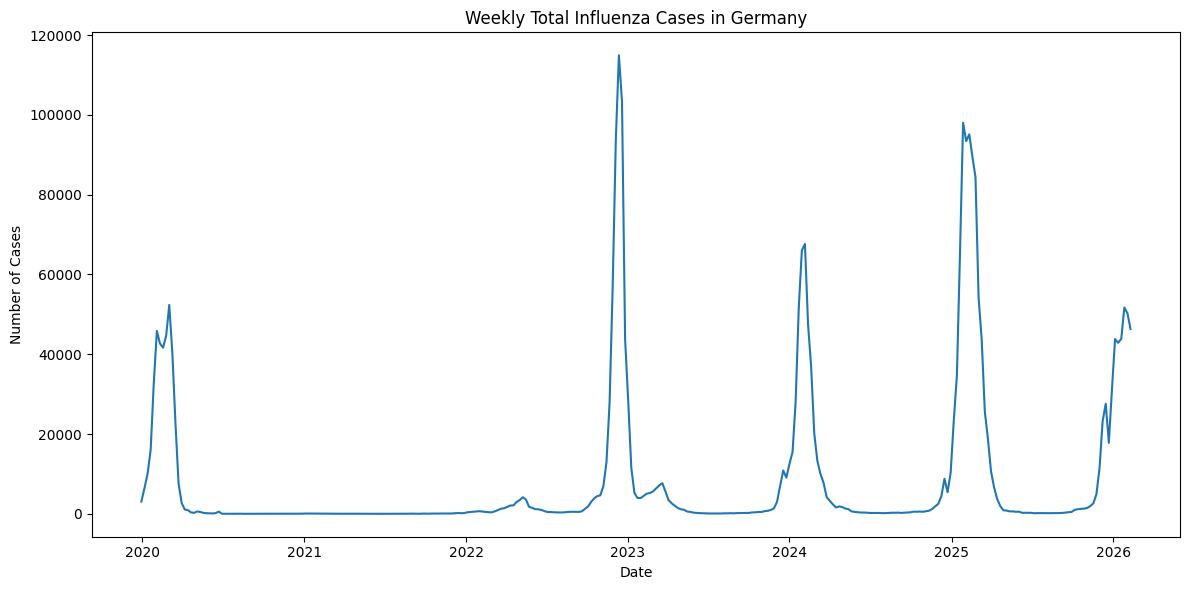

In [28]:
# Your code here
# Aggregate across age groups and ensure proper weekly frequency
total_cases_weekly = df.groupby(df.index)["Fallzahl"].sum()

# Plot the result
plt.figure(figsize=(12, 6))
plt.plot(total_cases_weekly)
plt.title("Weekly Total Influenza Cases in Germany")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.tight_layout()
plt.show()


### Task 1.2
Construct separate weekly time series for:

- 00-14  
- 15-59  
- 60+

Plot all series together.

Questions:
- Which age group peaks first? They peak around the same time
- Which age group has highest variance? 15-59
- Which appears smoothest? 60+


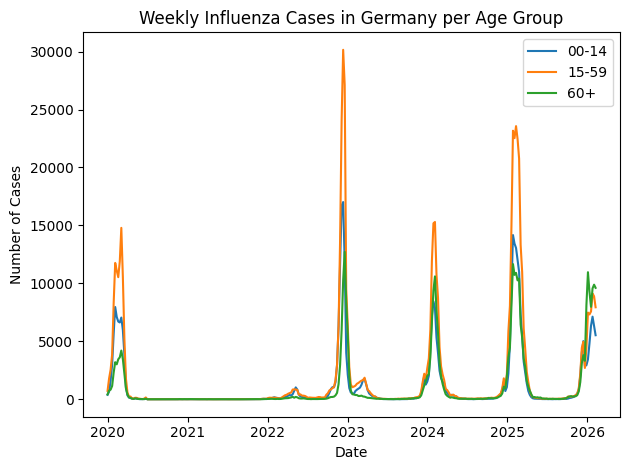

In [73]:
# Your code here
total_cases_weekly_00_14 = df[df['Altersgruppe']=="00-14"]["Fallzahl"]
total_cases_weekly_15_59 = df[df['Altersgruppe']=="15-59"]["Fallzahl"]
total_cases_weekly_60 = df[df['Altersgruppe']=="60+"]["Fallzahl"]

plt.plot(total_cases_weekly_00_14, label="00-14")
plt.plot(total_cases_weekly_15_59, label="15-59")
plt.plot(total_cases_weekly_60, label="60+")
plt.title("Weekly Influenza Cases in Germany per Age Group")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.legend()
plt.tight_layout()
plt.show()



# Part 2 — Autocorrelation Structure

For:
- Total series
- Each age group

Compute:
- ACF (lags up to 120)
- PACF

Questions:
- Do you observe seasonal peaks near lag ≈ 52? Yes, in the ACF even more than in the PACF
- Does short-lag ACF decay quickly or slowly? It decays quickly, drops from 1 to 0 in around 8 lags
- Which age group shows strongest persistence? 15-59


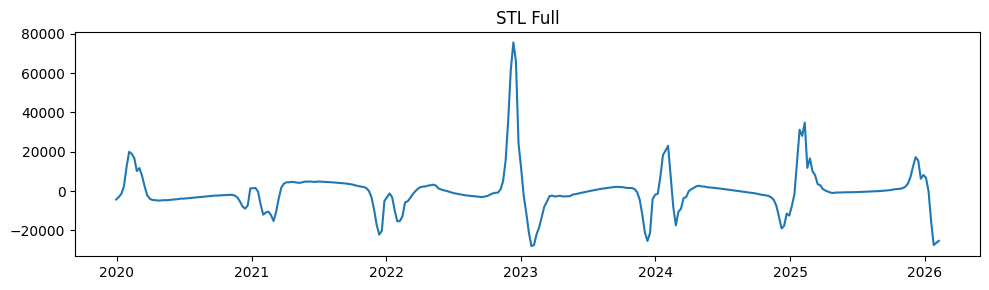

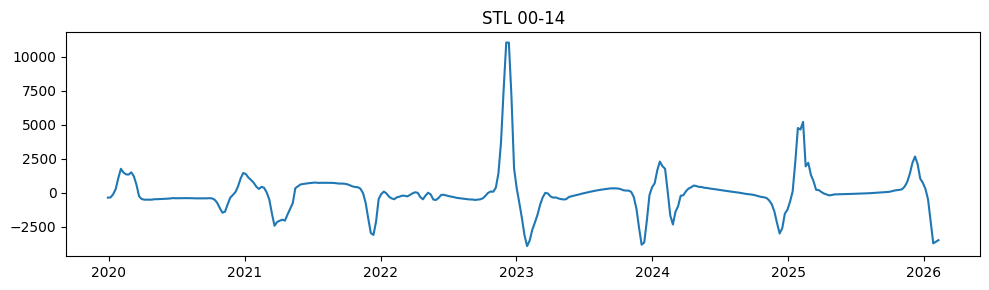

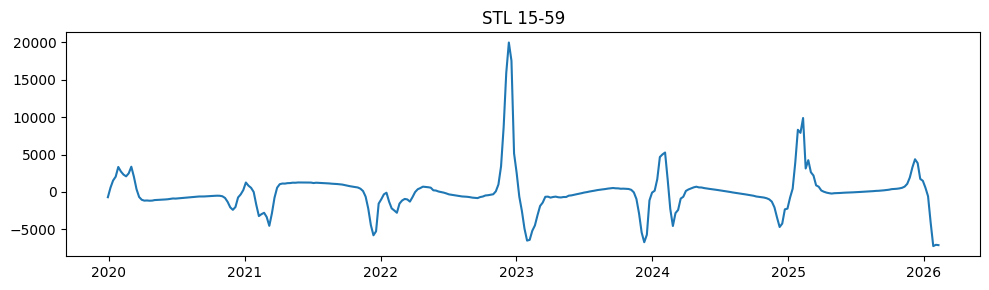

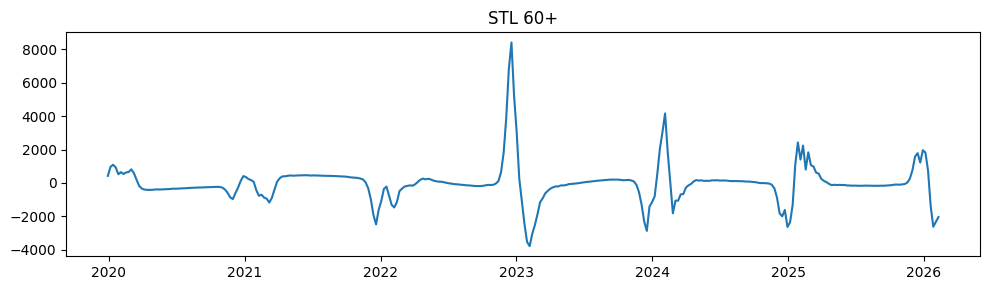

In [78]:
from statsmodels.tsa.seasonal import STL


stl_full = STL(total_cases_weekly, period=52).fit()
stl_00_14 = STL(total_cases_weekly_00_14, period=52).fit()
stl_15_59 = STL(total_cases_weekly_15_59, period=52).fit()
stl_60 = STL(total_cases_weekly_60, period=52).fit()


plt.figure(figsize=(10,3))
plt.plot(stl_full.resid)
plt.title("STL Full")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,3))
plt.plot(stl_00_14.resid)
plt.title("STL 00-14")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,3))
plt.plot(stl_15_59.resid)
plt.title("STL 15-59")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,3))
plt.plot(stl_60.resid)
plt.title("STL 60+")
plt.tight_layout()
plt.show()

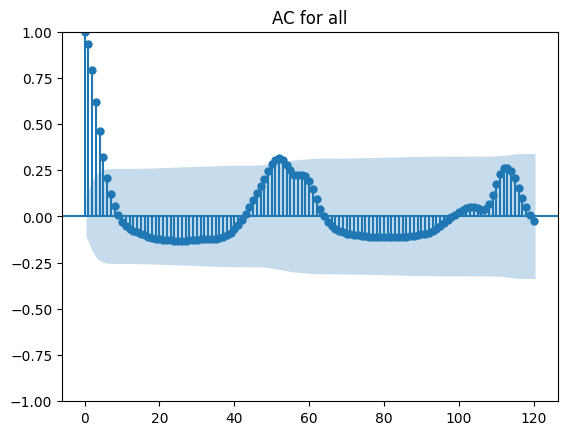

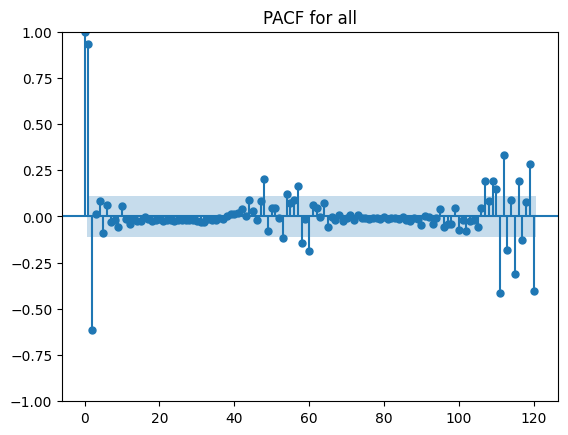

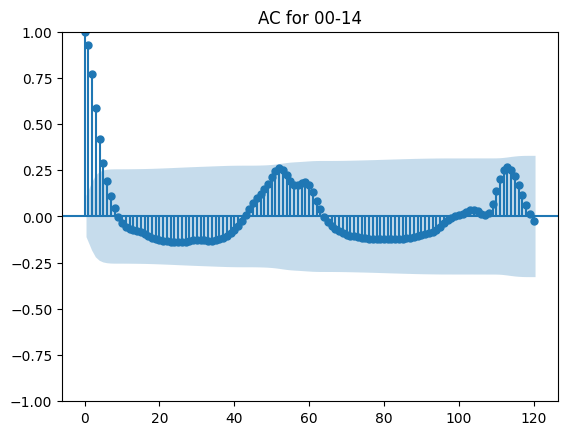

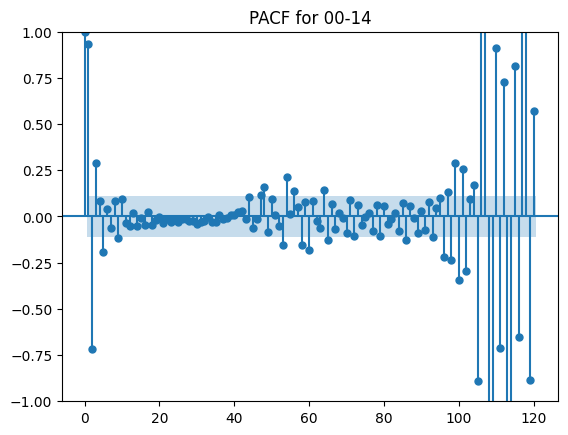

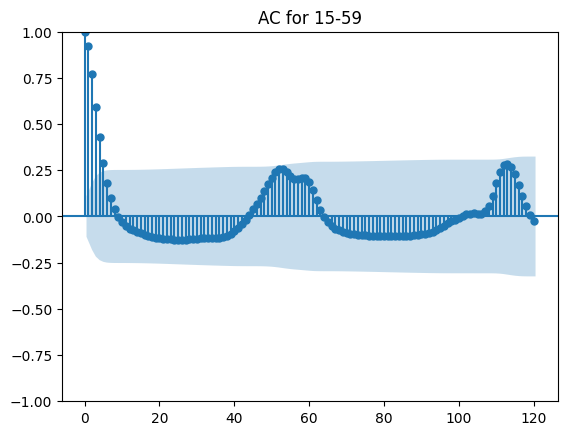

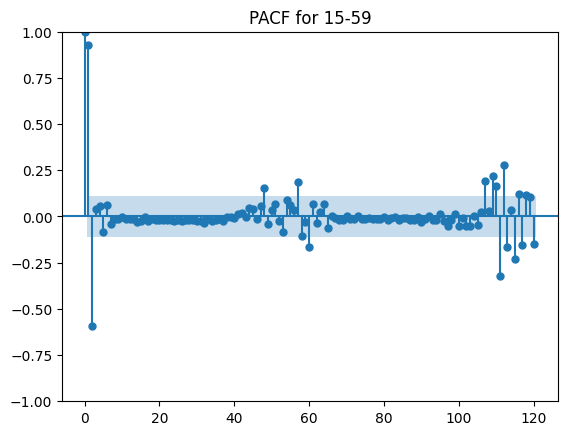

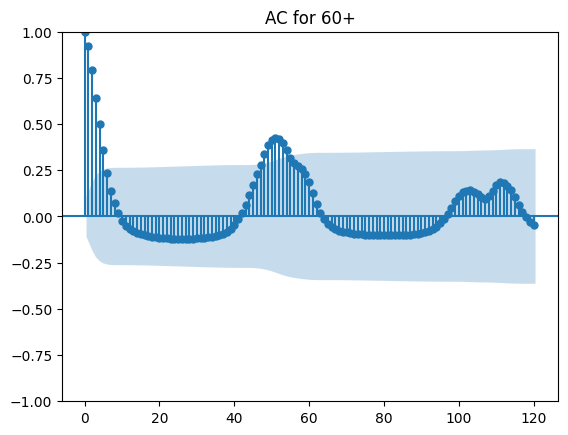

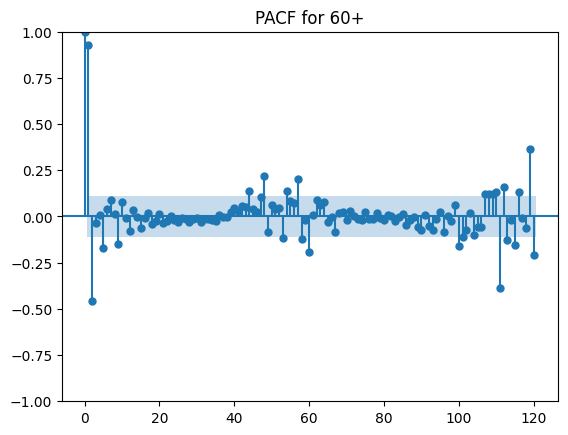

In [79]:
# Your code here
# with seasonality
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_autocorr(data, group, lags=120):
  plot_acf(data, lags=lags)
  plt.title(f"AC for {group}")
  plt.show()

  plot_pacf(data, lags=lags, method="ywadjusted")
  plt.title(f"PACF for {group}")
  plt.show()

plot_autocorr(total_cases_weekly, "all")
plot_autocorr(total_cases_weekly_00_14, "00-14")
plot_autocorr(total_cases_weekly_15_59, "15-59")
plot_autocorr(total_cases_weekly_60, "60+")


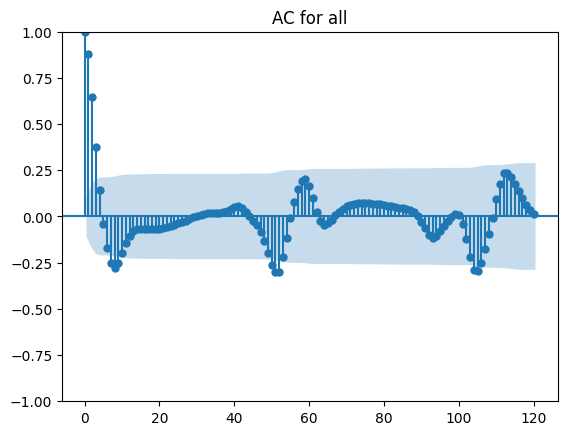

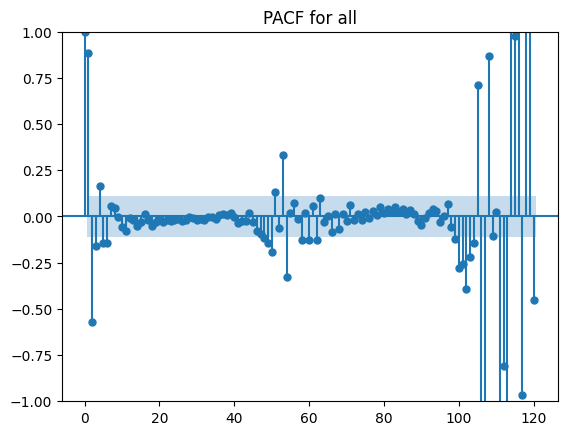

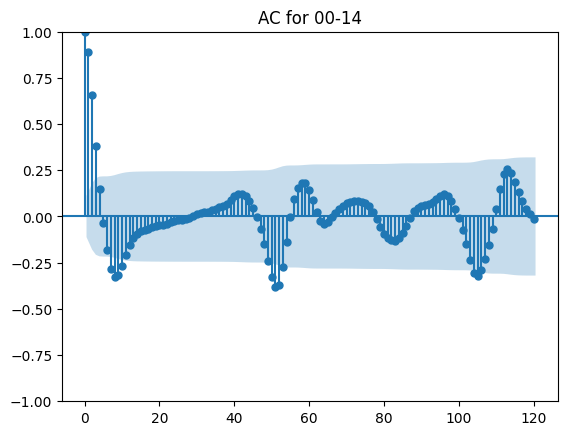

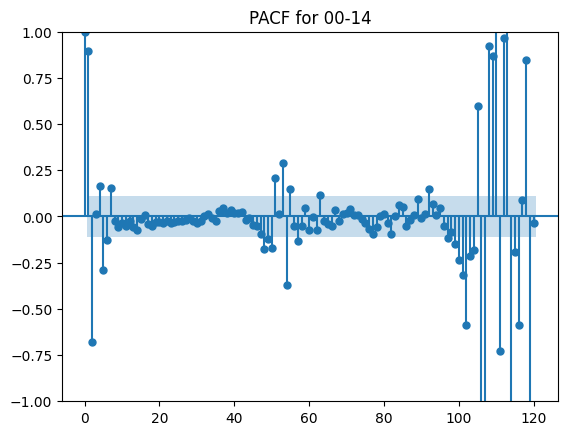

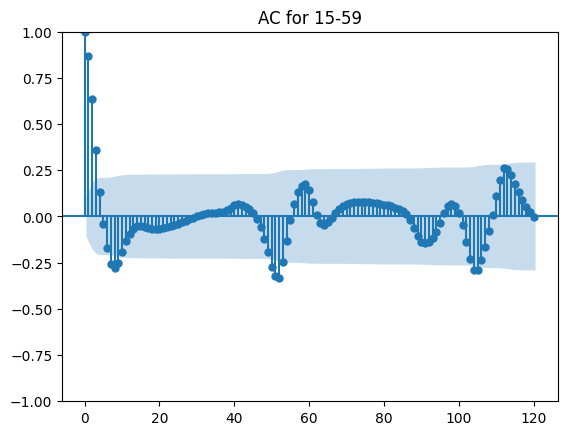

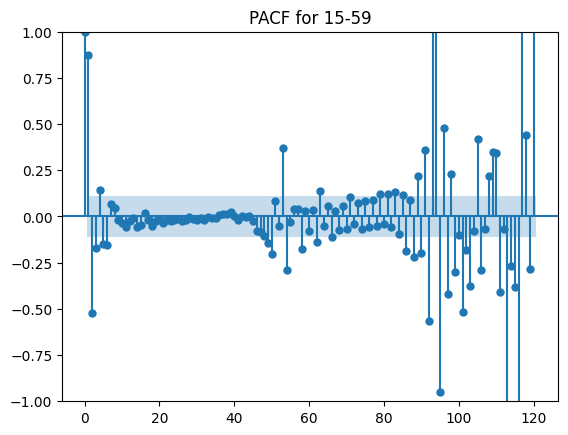

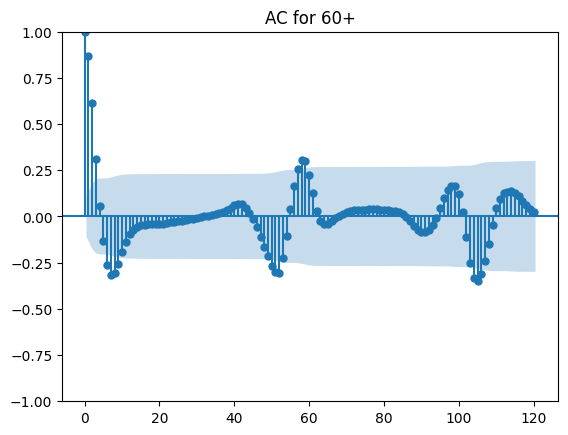

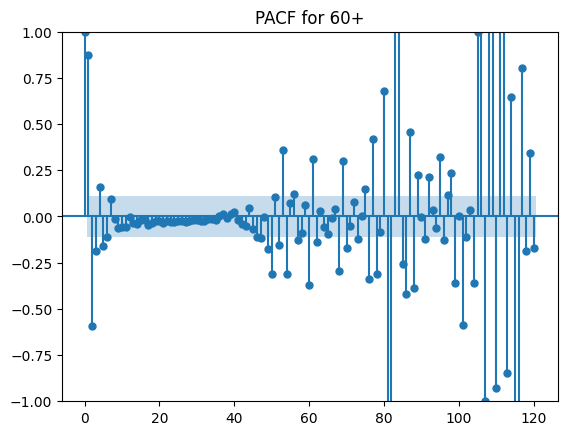

In [80]:
# without seasonality
plot_autocorr(stl_full.resid, "all")
plot_autocorr(stl_00_14.resid, "00-14")
plot_autocorr(stl_15_59.resid, "15-59")
plot_autocorr(stl_60.resid, "60+")


# Part 3 — Frequency Domain Analysis

Using a periodogram:

- Detect dominant frequency
- Convert frequency to period (in weeks)

Questions:
- Is dominant period near 52 weeks?
- Do age groups differ slightly?
- Is dominant period change during COVID era?


In [83]:
from scipy.signal import periodogram

In [90]:
# Your code here
def get_periodogram(data):
  freqs, power = periodogram(data, fs=1)

  # Identify dominant frequency
  dominant_freq = freqs[np.argmax(power)]
  dominant_period = 1 / dominant_freq

  print(f"Dominant frequency:", dominant_freq)
  print(f"Dominant period (weeks):", dominant_period)

get_periodogram(total_cases_weekly)
get_periodogram(total_cases_weekly_00_14)
get_periodogram(total_cases_weekly_15_59)
get_periodogram(total_cases_weekly_60)

Dominant frequency: 0.018750000000000003
Dominant period (weeks): 53.33333333333333
Dominant frequency: 0.01948051948051948
Dominant period (weeks): 51.333333333333336
Dominant frequency: 0.01892744479495268
Dominant period (weeks): 52.833333333333336
Dominant frequency: 0.0189873417721519
Dominant period (weeks): 52.666666666666664



# Part 4 — Temperature Coupling

Download weekly temperature for Germany ( Open-Meteo).

Tasks:
1. Align temperature with influenza series --> I have already defined start_date and end_date aligned by influenza but you need to replace your correct dataframe name insteaf of flu
2. Standardize both series
3. Compute cross-correlation for lags ±20 weeks

Questions:
- At what lag is correlation strongest?
- Does temperature lead flu or vice versa?
- Why might raw cross-correlation be misleading?


In [91]:
import requests
flu = total_cases_weekly

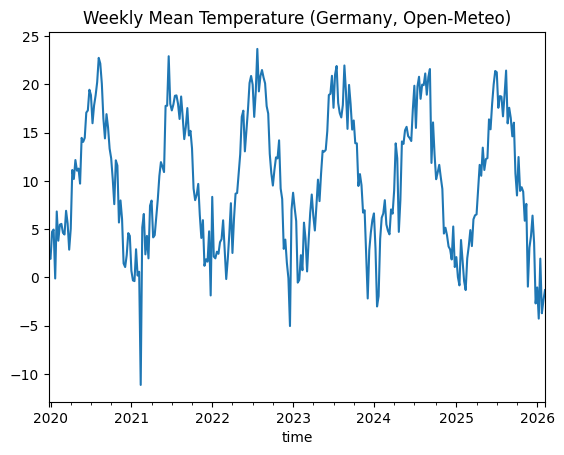

,temperature_2m_mean
time,
2019-12-30,2.100000
2020-01-06,1.914286
2020-01-13,4.728571
2020-01-20,4.957143
2020-01-27,-0.114286


In [92]:
start_date = flu.index.min().strftime("%Y-%m-%d")
end_date = flu.index.max().strftime("%Y-%m-%d")

api_url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=51.1657&longitude=10.4515"
    f"&start_date={start_date}&end_date={end_date}"
    "&daily=temperature_2m_mean"
    "&timezone=Europe/Berlin"
)

weather_json = requests.get(api_url).json()
temp_daily = pd.DataFrame(weather_json["daily"])
temp_daily["time"] = pd.to_datetime(temp_daily["time"])
temp_daily = temp_daily.set_index("time")

temp_weekly = temp_daily["temperature_2m_mean"].resample("W-MON").mean()

temp_weekly.plot(title="Weekly Mean Temperature (Germany, Open-Meteo)")
plt.show()

temp_weekly.head()


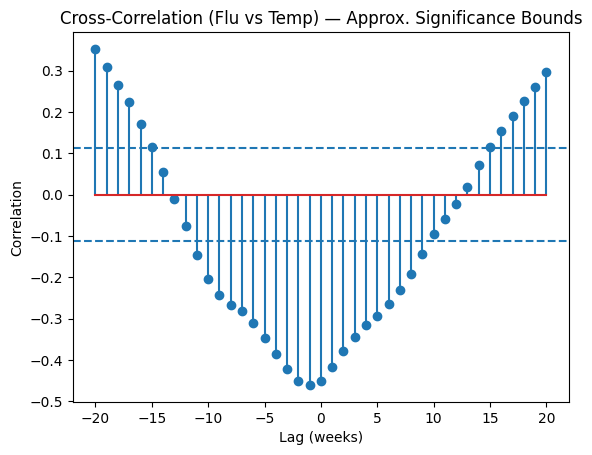

N = 320   threshold = 0.11180339887498948
Largest |corr| at lag = -1  value = 0.4600193383720498


In [97]:
# compute cross-correlation for 120 weeks
def cross_corr(x: np.ndarray, y: np.ndarray, max_lag: int = 20):
    """Compute Corr(x_t, y_{t-lag}) for lags in [-max_lag, +max_lag]."""
    lags = np.arange(-max_lag, max_lag + 1)
    values = []
    for lag in lags:
        if lag < 0:
            # correlate x_{t} with y_{t-(-lag)} = y_{t+lag}: x[-lag:] aligns with y[:lag]
            c = np.corrcoef(x[-lag:], y[:lag])[0, 1]
        elif lag > 0:
            c = np.corrcoef(x[:-lag], y[lag:])[0, 1]
        else:
            c = np.corrcoef(x, y)[0, 1]
        values.append(c)
    return lags, np.array(values)

max_lag = 20
lags, ccs = cross_corr(flu.values, temp_weekly.values, max_lag=max_lag)

N = len(flu.values)
threshold = 2 / np.sqrt(N)

plt.figure()
plt.stem(lags, ccs)
plt.axhline(threshold, linestyle="--")
plt.axhline(-threshold, linestyle="--")
plt.title("Cross-Correlation (Flu vs Temp) — Approx. Significance Bounds")
plt.xlabel("Lag (weeks)")
plt.ylabel("Correlation")
plt.show()

print("N =", N, "  threshold =", threshold)
print("Largest |corr| at lag =", lags[np.argmax(np.abs(ccs))], " value =", np.max(np.abs(ccs)))


# Part 5 — Prewhitening

Fit AR(p) model (e.g., p=2) to both influenza and temperature series.

- Extract residuals
- Compute cross-correlation of residuals

Questions:
- How much does correlation magnitude change?
- What does this imply about seasonal confounding?
- Do age groups differ in residual coupling?


In [ ]:
flu_00_14 = total_cases_weekly_00_14
flu_15_59 = total_cases_weekly_15_59
flu_60 = total_cases_weekly_60

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


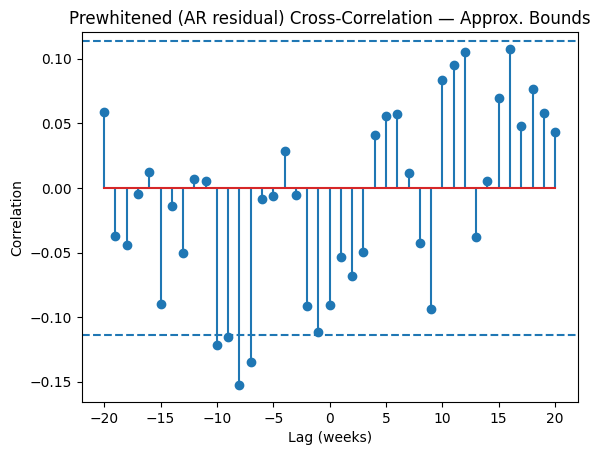

N3 = 308   threshold3 = 0.11396057645963795
Largest |corr| at lag = -8  value = 0.15248715681123884


In [102]:
from statsmodels.tsa.arima.model import ARIMA

def prewhiten_residuals(series: pd.Series, ar_order: int = 2) -> pd.Series:
    """Fit ARIMA(p,0,0) and return residuals aligned to index."""

    s = series.dropna()
    fit = ARIMA(s, order=(ar_order, 0, 0)).fit()
    r = fit.resid
    return r

p_f = 2
p_t = 2

f_resid = prewhiten_residuals(flu_00_14, ar_order=p_f)
t_resid = prewhiten_residuals(temp_weekly, ar_order=p_t)

resid_df = pd.concat([f_resid, t_resid], axis=1).dropna()
f_resid = resid_df.iloc[:, 0]
t_resid = resid_df.iloc[:, 1]

lags3, ccs3 = cross_corr(f_resid.values, t_resid.values, max_lag=max_lag)

N3 = len(f_resid)
threshold3 = 2 / np.sqrt(N3)

plt.figure()
plt.stem(lags3, ccs3)
plt.axhline(threshold3, linestyle="--")
plt.axhline(-threshold3, linestyle="--")
plt.title("Prewhitened (AR residual) Cross-Correlation — Approx. Bounds")
plt.xlabel("Lag (weeks)")
plt.ylabel("Correlation")
plt.show()

print("N3 =", N3, "  threshold3 =", threshold3)
print("Largest |corr| at lag =", lags[np.argmax(np.abs(ccs3))], " value =", np.max(np.abs(ccs3)))



# Part 6 — Structural Break Analysis (COVID vs Post-COVID)

Define:

- COVID era: 2020-03-01 to 2022-06-30  
- Post-COVID: 2022-07-01 onward  

Tasks:
1. Compare mean and variance across eras
2. Compare ACF patterns
3. Compare dominant period

Questions:
- What changed during COVID era?
- Why does dominant period shift?


In [112]:
# Define COVID era and Post-COVID era using total_cases_weekly
covid_era_cases = total_cases_weekly.loc["2020-03-01":"2022-06-30"]
post_covid_cases = total_cases_weekly.loc["2022-07-01":]

In [121]:
np.sum(post_covid_cases)

np.int64(2237226)

In [125]:
print(f"covid era mean: {np.mean(covid_era_cases)}" f" and post covid era mean: {np.mean(post_covid_cases)}")
print(f"covid era var: {np.var(covid_era_cases)}" f" and post covid era var: {np.var(post_covid_cases)}")

covid era mean: 1388.9016393442623 and post covid era mean: 11837.174603174602
covid era var: 39223255.744423576 and post covid era var: 538728094.1335348


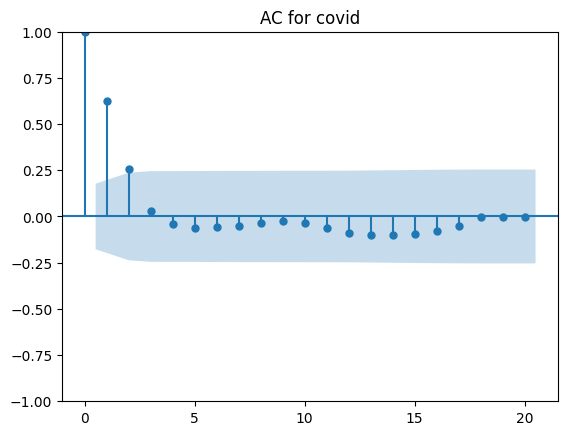

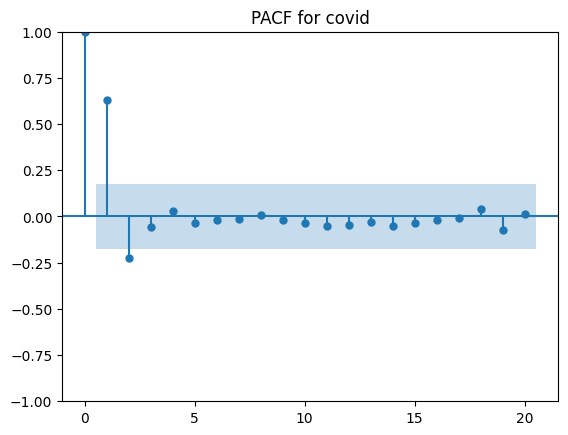

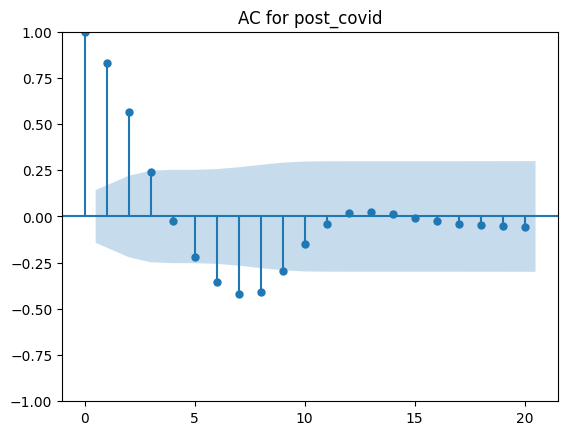

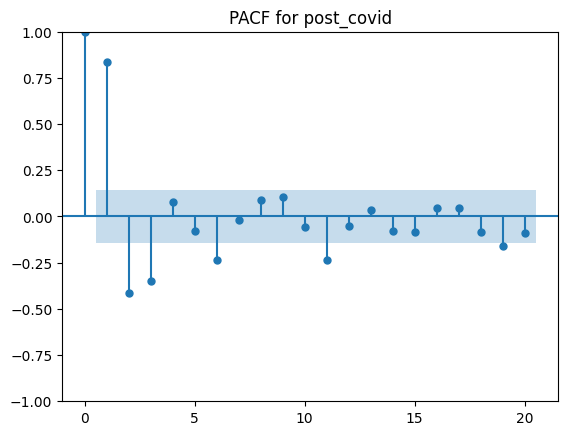

In [127]:
stl_covid_era = STL(covid_era_cases, period=52).fit()
stl_post_covid_era = STL(post_covid_cases, period=52).fit()

plot_autocorr(stl_covid_era.resid, "covid", 20)
plot_autocorr(stl_post_covid_era.resid, "post_covid", 20)

In [128]:
get_periodogram(covid_era_cases)
get_periodogram(post_covid_cases)

Dominant frequency: 0.00819672131147541
Dominant period (weeks): 122.0
Dominant frequency: 0.037037037037037035
Dominant period (weeks): 27.0
